# Set up directories

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# After confirming the location of  path, assign it to
# `FOLDERPATH` variable
FOLDERPATH = '/content/drive/MyDrive/labs/lab_3_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.insert(1, FOLDERPATH)

# Having the dataset, let's change directory to
# Lab2 folder again to continue with the exercise
%cd {FOLDERPATH}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/labs/lab_3_2024_2025


# GPU

You can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`.

## Setup

You should switch to GPU before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as datasets
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this tutorial.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


# Part I. Preparation

## Load CIFAR-10 dataset

Now, let's load the CIFAR-10 dataset.

To make the whole procedure more efficient, we managed to save the whole dataset in ``.npy`` files.

PyTorch provides some convenient tools to automate this process even more for us.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Define the mean and standard deviation for CIFAR-10
mean = (0.4914, 0.4822, 0.4465)  # Precomputed mean for CIFAR-10
std = (0.2023, 0.1994, 0.2010)   # Precomputed std for CIFAR-10

# Define the transform for preprocessing and data augmentation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load the CIFAR-10 dataset
dataset_path = '/content/drive/MyDrive/labs/'  # Replace with your dataset path
cifar10_dataset = datasets.CIFAR10(root=dataset_path, train=True, download=False, transform=transform) # Use download=True in case you do not have already downloaded

# Split the dataset into train, val, and test sets
num_train = 45000  # Number of training examples
num_val = 5000    # Number of validation examples
num_test = 10000   # Number of test examples (CIFAR-10 test set size)

train_dataset, val_dataset = random_split(cifar10_dataset, [num_train, num_val])

test_dataset = datasets.CIFAR10(root=dataset_path, train=False, download=True, transform=transform)

# Define DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes for verification
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Files already downloaded and verified
Train set size: 45000
Validation set size: 5000
Test set size: 10000


## Visualize the class distributions

We have now defined our train, validation and test dataloaders. However, it would be good to check the data distribution of each dataloader, in order to check how many examples per class are included. We do this as a sanity check, as we want our dataloaders to be distributed close to uniform. Let's define some helper functions:

In [ ]:
import numpy as np
from collections import Counter

def get_class_distribution(loader, dataset_classes):
    """
    Computes the distribution of classes in a DataLoader.

    Args:
    - loader: DataLoader to inspect
    - dataset_classes: List of class names for the dataset

    Returns:
    - class_counts: Dictionary with class names as keys and counts as values
    """
    class_counts = Counter()
    for inputs, labels in loader:
        class_counts.update(labels.numpy())

    # Convert to a dictionary with class names
    class_distribution = {dataset_classes[i]: class_counts[i] for i in range(len(dataset_classes))}
    return class_distribution

def display_class_distribution(distribution, title="Class Distribution"):
    """
    Displays the class distribution as a bar chart.

    Args:
    - distribution: Dictionary with class names as keys and counts as values
    - title: Title for the bar chart
    """
    import matplotlib.pyplot as plt

    class_names = list(distribution.keys())
    counts = list(distribution.values())

    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Now, let's visualize the distribution of the examples per class for each dataloader:

Train DataLoader Distribution:
  airplane: 4502
  automobile: 4505
  bird: 4502
  cat: 4483
  deer: 4476
  dog: 4527
  frog: 4511
  horse: 4503
  ship: 4532
  truck: 4459


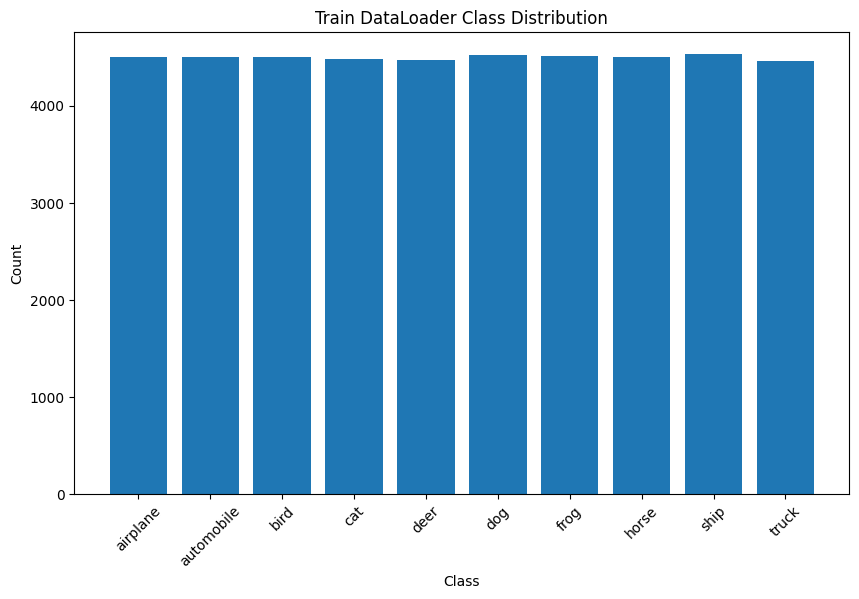

Validation DataLoader Distribution:
  airplane: 498
  automobile: 495
  bird: 498
  cat: 517
  deer: 524
  dog: 473
  frog: 489
  horse: 497
  ship: 468
  truck: 541


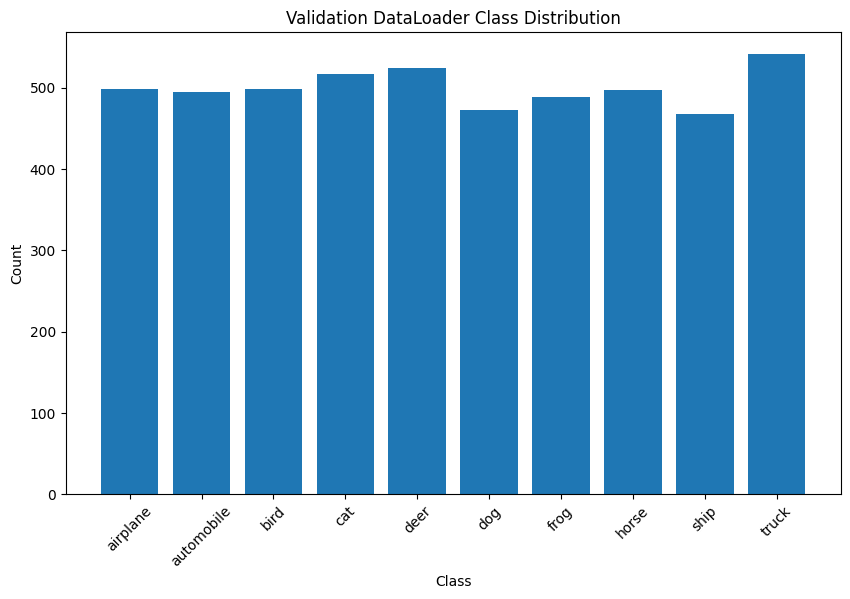

Test DataLoader Distribution:
  airplane: 1000
  automobile: 1000
  bird: 1000
  cat: 1000
  deer: 1000
  dog: 1000
  frog: 1000
  horse: 1000
  ship: 1000
  truck: 1000


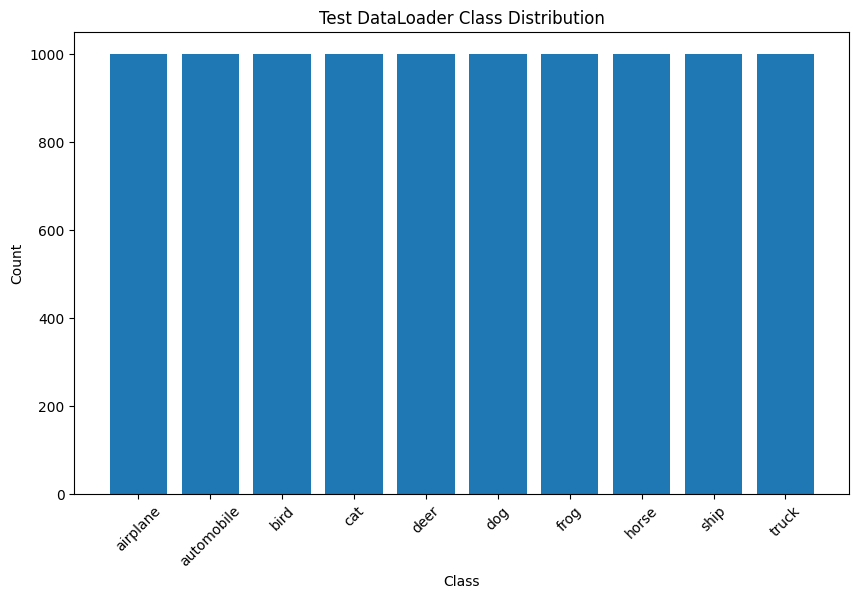

In [ ]:
# CIFAR-10 classes
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Compute and display class distribution for each DataLoader
for loader, name in [(train_loader, "Train"), (val_loader, "Validation"), (test_loader, "Test")]:
    distribution = get_class_distribution(loader, cifar10_classes)
    print(f"{name} DataLoader Distribution:")
    for cls, count in distribution.items():
        print(f"  {cls}: {count}")
    display_class_distribution(distribution, title=f"{name} DataLoader Class Distribution")

## Visualize CIFAR-10 images

Now let's visualize a few examples from each class in the CIFAR-10 dataset.

By displaying images alongside their corresponding class labels, we can verify the dataset’s contents and ensure the classes are represented correctly.

This visualization helps us understand the data distribution and provides insights into the dataset’s characteristics.

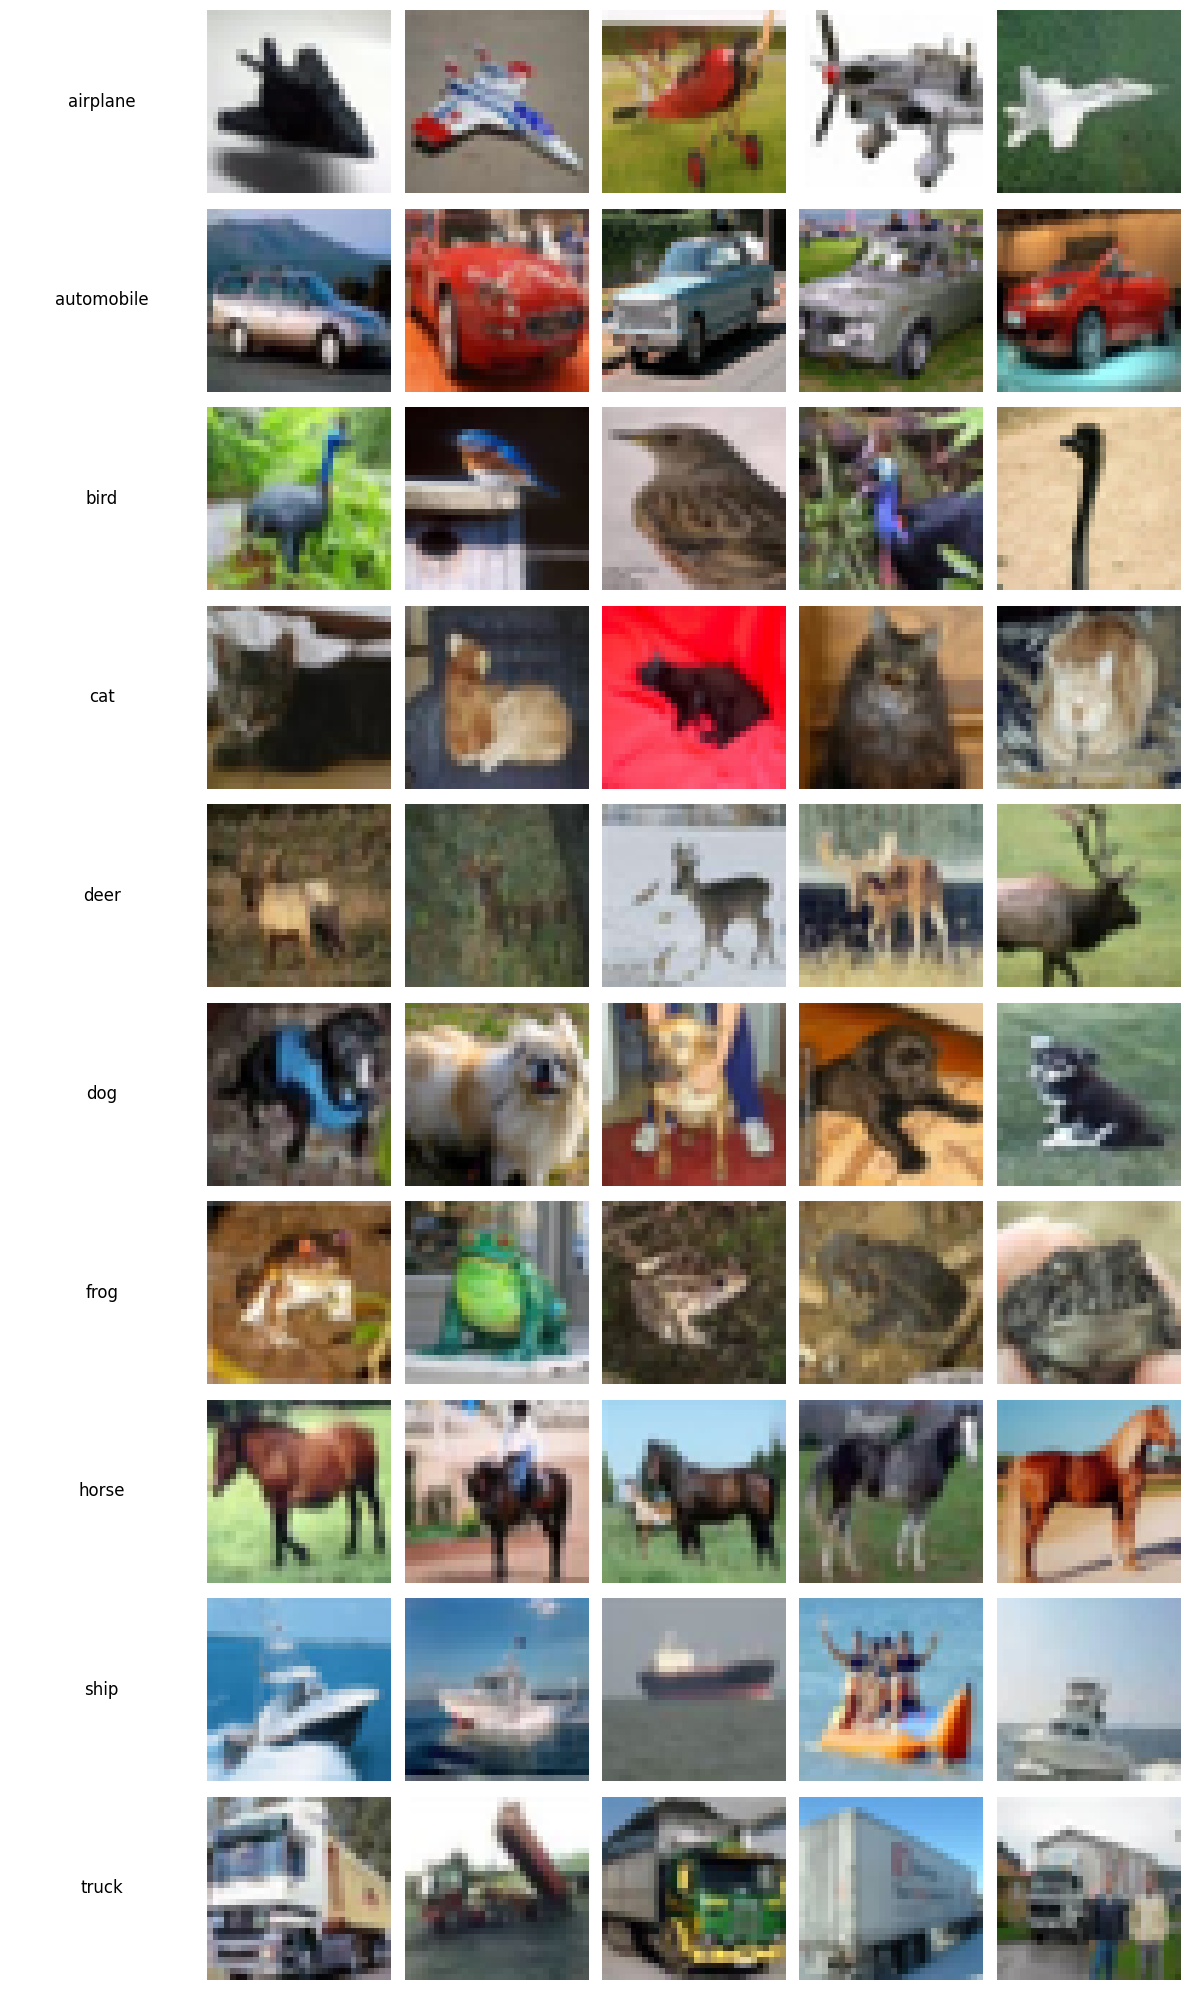

In [ ]:
import matplotlib.pyplot as plt

def visualize_images_per_class(dataset, dataset_classes, num_images=5):
    """
    Visualizes a few images from each class in the dataset.

    Args:
    - dataset: The dataset to sample from.
    - dataset_classes: List of class names for the dataset.
    - num_images: Number of images to display per class.
    """
    class_to_indices = {cls: [] for cls in range(len(dataset_classes))}

    # Group indices by class
    for idx, (_, label) in enumerate(dataset):
        if len(class_to_indices[label]) < num_images:
            class_to_indices[label].append(idx)
        if all(len(indices) == num_images for indices in class_to_indices.values()):
            break

    # Plot the images
    fig, axes = plt.subplots(len(dataset_classes), num_images + 1, figsize=((num_images + 1) * 2, len(dataset_classes) * 2))
    for cls_idx, cls_name in enumerate(dataset_classes):
        indices = class_to_indices[cls_idx]

        # Add class name to the first column of each row
        axes[cls_idx, 0].text(0.5, 0.5, cls_name, fontsize=12, ha='center', va='center', transform=axes[cls_idx, 0].transAxes)
        axes[cls_idx, 0].axis("off")

        for img_idx, data_idx in enumerate(indices):
            img, label = dataset[data_idx]
            ax = axes[cls_idx, img_idx + 1]  # Shift by 1 for the class name column
            img = img.permute(1, 2, 0)  # Convert CHW to HWC
            img = img * torch.tensor(std).view(1, 1, 3) + torch.tensor(mean).view(1, 1, 3)  # De-normalize
            img = torch.clamp(img, 0, 1)  # Clip values to valid range
            ax.imshow(img)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize 5 images per class for CIFAR-10 train set
visualize_images_per_class(cifar10_dataset, cifar10_classes, num_images=5)

# Part II. Three-Layer ConvNet with Barebone PyTorch

## Barebone PyTorch: Three-Layer ConvNet



Here we will complete the implementation of the function `three_layer_convnet`, which will perform the forward pass of a three-layer convolutional network. Like previously, we can immediately test our implementation by passing zeros through the network. The network should have the following architecture:

1. A convolutional layer (with bias) with `channel_1` filters, each with shape `KW1 x KH1`, and zero-padding of two
2. ReLU nonlinearity
3. A convolutional layer (with bias) with `channel_2` filters, each with shape `KW2 x KH2`, and zero-padding of one
4. ReLU nonlinearity
5. Fully-connected layer with bias, producing scores for C classes.

Note that we have **no softmax activation** here after our fully-connected layer: this is because PyTorch's cross entropy loss performs a softmax activation for us, and by bundling that step in makes computation more efficient.

**HINT**: For convolutions: http://pytorch.org/docs/stable/nn.html#torch.nn.functional.conv2d; pay attention to the shapes of convolutional filters!

In [ ]:
def three_layer_convnet(x, params):
    """
    Performs the forward pass of a three-layer convolutional network with the
    architecture defined above.

    Inputs:
    - x: A PyTorch Tensor of shape (N, 3, H, W) giving a minibatch of images
    - params: A list of PyTorch Tensors giving the weights and biases for the
      network; should contain the following:
      - conv_w1: PyTorch Tensor of shape (channel_1, 3, KH1, KW1) giving weights
        for the first convolutional layer
      - conv_b1: PyTorch Tensor of shape (channel_1,) giving biases for the first
        convolutional layer
      - conv_w2: PyTorch Tensor of shape (channel_2, channel_1, KH2, KW2) giving
        weights for the second convolutional layer
      - conv_b2: PyTorch Tensor of shape (channel_2,) giving biases for the second
        convolutional layer
      - fc_w: PyTorch Tensor giving weights for the fully-connected layer. Can you
        figure out what the shape should be?
      - fc_b: PyTorch Tensor giving biases for the fully-connected layer. Can you
        figure out what the shape should be?

    Returns:
    - scores: PyTorch Tensor of shape (N, C) giving classification scores for x
    """
    conv_w1, conv_b1, conv_w2, conv_b2, fc_w, fc_b = params
    scores = None
    
    # We mplement the forward pass for the three-layer ConvNet.                
    

    x = F.conv2d(x, conv_w1, bias=conv_b1, padding=2)
    x = F.relu(x)

    x = F.conv2d(x, conv_w2, bias=conv_b2, padding=1)
    x = F.relu(x)

    x = x.view(x.size(0), -1)

    if fc_w.shape[1] == x.shape[1]:
        scores = F.linear(x, fc_w, bias=fc_b)
    elif fc_w.shape[0] == x.shape[1]:
        scores = F.linear(x, fc_w.t(), bias=fc_b)
    else:
        raise ValueError("fc_w dimensions do not match the input dimensions.")

    return scores

After defining the forward pass of the ConvNet above, we run the following cell to test our implementation.

When we run this function, scores should have shape (64, 10).

In [ ]:
def three_layer_convnet_test():
    x = torch.zeros((64, 3, 32, 32), dtype=dtype)  # minibatch size 64, image size [3, 32, 32]

    conv_w1 = torch.zeros((6, 3, 5, 5), dtype=dtype)  # [out_channel, in_channel, kernel_H, kernel_W]
    conv_b1 = torch.zeros((6,))  # out_channel
    conv_w2 = torch.zeros((9, 6, 3, 3), dtype=dtype)  # [out_channel, in_channel, kernel_H, kernel_W]
    conv_b2 = torch.zeros((9,))  # out_channel

    # you must calculate the shape of the tensor after two conv layers, before the fully-connected layer
    fc_w = torch.zeros((9 * 32 * 32, 10))
    fc_b = torch.zeros(10)

    scores = three_layer_convnet(x, [conv_w1, conv_b1, conv_w2, conv_b2, fc_w, fc_b])
    print(scores.size())  # you should see [64, 10]
three_layer_convnet_test()

torch.Size([64, 10])


## Barebone PyTorch: Initialization

Let's write a couple utility methods to initialize the weight matrices for our models.

- `random_weight(shape)` initializes a weight tensor with the Kaiming normalization method.
- `zero_weight(shape)` initializes a weight tensor with all zeros. Useful for instantiating bias parameters.

The `random_weight` function uses the Kaiming normal initialization method, described in:

He et al, *Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification*, ICCV 2015, https://arxiv.org/abs/1502.01852

In [ ]:
def random_weight(shape):
    """
    Create random Tensors for weights; setting requires_grad=True means that we
    want to compute gradients for these Tensors during the backward pass.
    We use Kaiming normalization: sqrt(2 / fan_in)
    """
    if len(shape) == 2:  # FC weight
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:]) # conv weight [out_channel, in_channel, kH, kW]
    # randn is standard normal distribution generator.
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

# create a weight of shape [3 x 5]
# you should see the type `torch.cuda.FloatTensor` if you use GPU.
# Otherwise it should be `torch.FloatTensor`
random_weight((3, 5))

tensor([[-1.1533, -1.3013,  0.4624,  0.1734, -0.8394],
        [ 0.5297, -0.8091,  1.0567,  1.0620,  1.1056],
        [ 0.3545,  0.6658,  0.4140,  0.2373,  0.0705]], device='cuda:0',
       requires_grad=True)

## Barebone PyTorch: Check Accuracy

When training the model we will use the following function to check the accuracy of our model on the training or validation sets.

When checking accuracy we don't need to compute any gradients; as a result we don't need PyTorch to build a computational graph for us when we compute scores. To prevent a graph from being built we scope our computation under a `torch.no_grad()` context manager.

In [ ]:
def check_accuracy_part2(loader, model_fn, params):
    """
    Check the accuracy of a classification model.

    Inputs:
    - loader: A DataLoader for the data split we want to check
    - model_fn: A function that performs the forward pass of the model,
      with the signature scores = model_fn(x, params)
    - params: List of PyTorch Tensors giving parameters of the model

    Returns: Nothing, but prints the accuracy of the model
    """
    #split = 'val' if loader.dataset.train else 'test'
    split = 'val' if len(loader) == 79 else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

## BareBone PyTorch: Training Loop

We can now set up a basic training loop to train our network. We will train the model using stochastic gradient descent without momentum. We will use `torch.functional.cross_entropy` to compute the loss; you can [read about it here](http://pytorch.org/docs/stable/nn.html#cross-entropy).

The training loop takes as input the neural network function, a list of initialized parameters (`[w1, w2]` in our example), and learning rate.

In [ ]:
def train_part2(model_fn, params, learning_rate):
    """
    Train a model on CIFAR-10.

    Inputs:
    - model_fn: A Python function that performs the forward pass of the model.
      It should have the signature scores = model_fn(x, params) where x is a
      PyTorch Tensor of image data, params is a list of PyTorch Tensors giving
      model weights, and scores is a PyTorch Tensor of shape (N, C) giving
      scores for the elements in x.
    - params: List of PyTorch Tensors giving weights for the model
    - learning_rate: Python scalar giving the learning rate to use for SGD

    Returns: Nothing
    """
    for t, (x, y) in enumerate(train_loader):
        # Move the data to the proper device (GPU or CPU)
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)

        # Forward pass: compute scores and loss
        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)

        # Backward pass: PyTorch figures out which Tensors in the computational
        # graph has requires_grad=True and uses backpropagation to compute the
        # gradient of the loss with respect to these Tensors, and stores the
        # gradients in the .grad attribute of each Tensor.
        loss.backward()

        # Update parameters. We don't want to backpropagate through the
        # parameter updates, so we scope the updates under a torch.no_grad()
        # context manager to prevent a computational graph from being built.
        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad

                # Manually zero the gradients after running the backward pass
                w.grad.zero_()

        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy_part2(val_loader, model_fn, params)
            print()

## BareBone PyTorch: Training a ConvNet



We will use the functions defined above to train a three-layer convolutional network on CIFAR-10. The network should have the following architecture:

1. Convolutional layer (with bias) with 32 5x5 filters, with zero-padding of 2
2. ReLU
3. Convolutional layer (with bias) with 16 3x3 filters, with zero-padding of 1
4. ReLU
5. Fully-connected layer (with bias) to compute scores for 10 classes

We will  initialize our weight matrices using the `random_weight` function defined above, and we will initialize our bias vectors using the `zero_weight` function above.

Then train for one epoch 

In [ ]:
learning_rate = 3e-4

channel_1 = 32
channel_2 = 16

conv_w1 = None
conv_b1 = None
conv_w2 = None
conv_b2 = None
fc_w = None
fc_b = None


# We initialize the parameters of a three-layer ConvNet.           

conv_w1 = random_weight((channel_1, 3, 5, 5))
conv_b1 = zero_weight((channel_1,))

conv_w2 = random_weight((channel_2, channel_1, 3, 3))
conv_b2 = zero_weight((channel_2,))

input_height = 32
input_width = 32

h1 = input_height
w1 = input_width

h2 = h1
w2 = w1
flattened_size = channel_2 * h2 * w2

fc_w = random_weight((10, flattened_size))
fc_b = zero_weight((10,))

params = [conv_w1, conv_b1, conv_w2, conv_b2, fc_w, fc_b]
train_part2(three_layer_convnet, params, learning_rate)


Iteration 0, loss = 79.4524
Checking accuracy on the val set
Got 419 / 5000 correct (8.38%)

Iteration 100, loss = 3.0389
Checking accuracy on the val set
Got 490 / 5000 correct (9.80%)

Iteration 200, loss = 2.4712
Checking accuracy on the val set
Got 507 / 5000 correct (10.14%)

Iteration 300, loss = 2.3991
Checking accuracy on the val set
Got 531 / 5000 correct (10.62%)

Iteration 400, loss = 2.3813
Checking accuracy on the val set
Got 542 / 5000 correct (10.84%)

Iteration 500, loss = 2.3761
Checking accuracy on the val set
Got 557 / 5000 correct (11.14%)

Iteration 600, loss = 2.3059
Checking accuracy on the val set
Got 563 / 5000 correct (11.26%)

Iteration 700, loss = 2.3442
Checking accuracy on the val set
Got 573 / 5000 correct (11.46%)



# Part III. Three-Layer ConvNet with PyTorch Module API

## Module API: Three-Layer ConvNet



Now, let's implement a 3-layer ConvNet followed by a fully connected layer using the `Module API`. The network architecture should be the same as in Part II:

1. Convolutional layer with `channel_1` 5x5 filters with zero-padding of 2
2. ReLU
3. Convolutional layer with `channel_2` 3x3 filters with zero-padding of 1
4. ReLU
5. Fully-connected layer to `num_classes` classes

We will initialize the weight matrices of the model using the Kaiming normal initialization method.

**HINT**: http://pytorch.org/docs/stable/nn.html#conv2d

We will  implement the three-layer ConvNet, the `test_ThreeLayerConvNet` function will run our implementation; it should print `(64, 10)` for the shape of the output scores.

In [ ]:
class ThreeLayerConvNet(nn.Module):
    def __init__(self, in_channel, channel_1, channel_2, num_classes):
        super().__init__()
        
        # We set up the layers you need for a three-layer ConvNet with the  
        # architecture defined above.                                          
      
        self.conv1 = nn.Conv2d(in_channel, channel_1, kernel_size=5, padding=2)

        self.conv2 = nn.Conv2d(channel_1, channel_2, kernel_size=3, padding=1)

        self.fc = nn.Linear(channel_2 * 32 * 32, num_classes)

        nn.init.kaiming_normal_(self.conv1.weight, mode='fan_out', nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, mode='fan_out', nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc.weight, mode='fan_out', nonlinearity='relu')

        nn.init.zeros_(self.conv1.bias)
        nn.init.zeros_(self.conv2.bias)
        nn.init.zeros_(self.fc.bias)
       

    def forward(self, x):
        scores = None
       
        # We implement the forward function for a 3-layer ConvNet.                              
    
        x = F.relu(self.conv1(x))

        x = F.relu(self.conv2(x))

        x = x.view(x.size(0), -1)


        scores = self.fc(x)
        
        return scores


def test_ThreeLayerConvNet():
    x = torch.zeros((64, 3, 32, 32), dtype=dtype)  # minibatch size 64, image size [3, 32, 32]
    model = ThreeLayerConvNet(in_channel=3, channel_1=12, channel_2=8, num_classes=10)
    scores = model(x)
    print(scores.size())  # you should see [64, 10]
test_ThreeLayerConvNet()

torch.Size([64, 10])


## Module API: Check Accuracy

Given the validation or test set, we can check the classification accuracy of a neural network.

This version is slightly different from the one in part II. We don't manually pass in the parameters anymore.

In [ ]:
def check_accuracy_part3(loader, model):
    split = 'val' if len(loader) == 79 else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    model.eval()  # set model to evaluation mode
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))

## Module API: Training Loop


We also use a slightly different training loop. Rather than updating the values of the weights ourselves, we use an Optimizer object from the `torch.optim` package, which abstract the notion of an optimization algorithm and provides implementations of most of the algorithms commonly used to optimize neural networks.

In [ ]:
def train_part3(model, optimizer, epochs=1):
    """
    Train a model on EuroSAT using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for

    Returns: Nothing, but prints model accuracies during training.
    """
    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(epochs):
        for t, (x, y) in enumerate(train_loader):
            model.train()  # put model to training mode
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            # Zero out all of the gradients for the variables which the optimizer
            # will update.
            optimizer.zero_grad()

            # This is the backwards pass: compute the gradient of the loss with
            # respect to each  parameter of the model.
            loss.backward()

            # Actually update the parameters of the model using the gradients
            # computed by the backwards pass.
            optimizer.step()

            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                check_accuracy_part3(val_loader, model)
                print()

## Module API: Train a Three-Layer ConvNet

We should now use the Module API to train a three-layer ConvNet on CIFAR-10. 
Train for one epoch 

We will train the model by using stochastic gradient descent without momentum.

In [ ]:
learning_rate = 3e-4
channel_1 = 32
channel_2 = 16

model = None
optimizer = None

# Instantiate our ThreeLayerConvNet model and a corresponding optimizer 
model = ThreeLayerConvNet(in_channel=3, channel_1=channel_1, channel_2=channel_2, num_classes=10)

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_part3(model, optimizer)

Iteration 0, loss = 57.6873
Checking accuracy on the val set
Got 519 / 5000 correct (10.38)

Iteration 100, loss = 3.2899
Checking accuracy on the val set
Got 649 / 5000 correct (12.98)

Iteration 200, loss = 2.5941
Checking accuracy on the val set
Got 614 / 5000 correct (12.28)

Iteration 300, loss = 2.4296
Checking accuracy on the val set
Got 638 / 5000 correct (12.76)

Iteration 400, loss = 2.5663
Checking accuracy on the val set
Got 667 / 5000 correct (13.34)

Iteration 500, loss = 2.5749
Checking accuracy on the val set
Got 699 / 5000 correct (13.98)

Iteration 600, loss = 2.3339
Checking accuracy on the val set
Got 718 / 5000 correct (14.36)

Iteration 700, loss = 2.3284
Checking accuracy on the val set
Got 718 / 5000 correct (14.36)



# Part IV. Three-Layer ConvNet with PyTorch Sequential API

## Sequential API: Three-Layer ConvNet



Here we should use `nn.Sequential` to define and train a three-layer ConvNet with the same architecture we used in Part III:

1. Convolutional layer (with bias) with 32 5x5 filters, with zero-padding of 2
2. ReLU
3. Convolutional layer (with bias) with 16 3x3 filters, with zero-padding of 1
4. ReLU
5. Fully-connected layer (with bias) to compute scores for 10 classes

We can use the default PyTorch weight initialization.

We should optimize our model using stochastic gradient descent with Nesterov momentum 0.9. and train for one epoch 

In [ ]:
channel_1 = 32
channel_2 = 16
learning_rate = 3e-4

model = None
optimizer = None


# Rewrite the 2-layer ConvNet with bias from Part III with the Sequential API.                                                              

model = nn.Sequential(

    nn.Conv2d(in_channels=3, out_channels=channel_1, kernel_size=5, padding=2, bias=True),
    nn.ReLU(),

    nn.Conv2d(in_channels=channel_1, out_channels=channel_2, kernel_size=3, padding=1, bias=True),
    nn.ReLU(),

    nn.Flatten(),

    nn.Linear(channel_2 * 32 * 32, 10, bias=True)
)


optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, nesterov=True)

train_part3(model, optimizer)

Iteration 0, loss = 2.2966
Checking accuracy on the val set
Got 432 / 5000 correct (8.64)

Iteration 100, loss = 2.1671
Checking accuracy on the val set
Got 1283 / 5000 correct (25.66)

Iteration 200, loss = 1.9794
Checking accuracy on the val set
Got 1575 / 5000 correct (31.50)

Iteration 300, loss = 2.1789
Checking accuracy on the val set
Got 1761 / 5000 correct (35.22)

Iteration 400, loss = 1.8231
Checking accuracy on the val set
Got 1890 / 5000 correct (37.80)

Iteration 500, loss = 1.8080
Checking accuracy on the val set
Got 1978 / 5000 correct (39.56)

Iteration 600, loss = 1.7179
Checking accuracy on the val set
Got 2104 / 5000 correct (42.08)

Iteration 700, loss = 1.6141
Checking accuracy on the val set
Got 2171 / 5000 correct (43.42)



## Sequential API: Experiment with Optimizers



Given the baseline three-layer convolutional network model implemented with PyTorch's Sequential API (as defined above), our next step is to train this model for 1 epoch using as **optimizers**: `SGD with momentum`, `Adagrad`, `RMSProp`, `Adam`, `AdamW` and `NAdam`, 

1. Refer to the PyTorch documentation about [optimizers](https://pytorch.org/docs/stable/optim.html.) to implement these optimizers.

2. We perform a learning rate search for each optimizer to find the learning rate that yields the best accuracy on the validation set.

For our convenience we will use:

- `channel_1 = 32`, `channel_2 = 16`.

- Utilize the `train_part3` function for training.

We'll probably have to modify the `check_accuracy_part3()` function to return the computed accuracy (as a percentage).


In [ ]:
def check_accuracy_part3(loader, model):
    """
    Check the accuracy of a classification model using nn.Module API.

    Inputs:
    - loader: A DataLoader for the data split we want to check.
    - model: A PyTorch model instance (subclass of nn.Module).

    Returns:
    - acc: Accuracy of the model on the dataset (as a percentage).
    """
    split = 'val' if len(loader) == 79 else 'test'
    print('Checking accuracy on the %s set' % split)

    num_correct, num_samples = 0, 0
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient computation
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # Move input to device
            y = y.to(device=device, dtype=torch.long)  # Move labels to device with correct dtype

            # Forward pass using the model
            scores = model(x)
            _, preds = scores.max(1)  # Get class predictions

            num_correct += (preds == y).sum().item()  # Increment correct predictions
            num_samples += preds.size(0)  # Increment total samples

    acc = (float(num_correct) / num_samples) * 100
    print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, acc))
    return acc

In [ ]:
import pandas as pd
channel_1 = 32
channel_2 = 16
learning_rates = [1e-1, 1e-2, 1e-3, 1e-4]

# Define the optimizers to test
optimizers_to_test = {
    "SGD": lambda model, lr: torch.optim.SGD(model.parameters(), lr=lr),
    "SGD with momentum": lambda model, lr: torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True),
    "Adagrad": lambda model, lr: torch.optim.Adagrad(model.parameters(), lr=lr),
    "RMSProp": lambda model, lr: torch.optim.RMSprop(model.parameters(), lr=lr),
    "Adam": lambda model, lr: torch.optim.Adam(model.parameters(), lr=lr),
    "AdamW": lambda model, lr: torch.optim.AdamW(model.parameters(), lr=lr),
    "NAdam": lambda model, lr: torch.optim.NAdam(model.parameters(), lr=lr),
}

results = []


# We test the three-layer ConvNet with different optimizers and learning    
# rates. We are use `train_part3()` for training and `check_accuracy_part3()` to      
# evaluate validation accuracy.                                                

best_results_per_optimizer = {}

print("Starting Training with Different Optimizers and Learning Rates\n")

for optimizer_name, optimizer_func in optimizers_to_test.items():
    best_accuracy = 0
    best_lr = None

    for lr in learning_rates:
        print(f"Testing {optimizer_name} with learning rate {lr}")

        model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=channel_1, kernel_size=5, padding=2, bias=True),
            nn.ReLU(),
            nn.Conv2d(in_channels=channel_1, out_channels=channel_2, kernel_size=3, padding=1, bias=True),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(channel_2 * 32 * 32, 10, bias=True)
        )

        model = model.to(device)

        optimizer = optimizer_func(model, lr)

        train_part3(model, optimizer)

        acc = check_accuracy_part3(val_loader, model)

        print(f"Validation Accuracy: {acc:.2f}%\n")

        results.append({
            "Optimizer": optimizer_name,
            "Learning Rate": lr,
            "Validation Accuracy": acc
        })

        if acc > best_accuracy:
            best_accuracy = acc
            best_lr = lr

    best_results_per_optimizer[optimizer_name] = {
        "Learning Rate": best_lr,
        "Validation Accuracy": best_accuracy
    }

results = sorted(results, key=lambda x: x["Validation Accuracy"], reverse=True)

print("\nBest Configurations:")
for result in results[:5]:
    print(f"Optimizer: {result['Optimizer']}, Learning Rate: {result['Learning Rate']:.4f}, Validation Accuracy: {result['Validation Accuracy']:.2f}%")

print("\nBest Classification Results Per Optimizer:")
table_data = []
for optimizer, data in best_results_per_optimizer.items():
    table_data.append({
        "Optimizer": optimizer,
        "Best Learning Rate": data["Learning Rate"],
        "Validation Accuracy (%)": data["Validation Accuracy"]
    })


df = pd.DataFrame(table_data)
print(df)

Starting Training with Different Optimizers and Learning Rates

Testing SGD with learning rate 0.1
Iteration 0, loss = 2.3243
Checking accuracy on the val set
Got 710 / 5000 correct (14.20%)

Iteration 100, loss = 2.2955
Checking accuracy on the val set
Got 517 / 5000 correct (10.34%)

Iteration 200, loss = 2.3022
Checking accuracy on the val set
Got 533 / 5000 correct (10.66%)

Iteration 300, loss = 2.2983
Checking accuracy on the val set
Got 468 / 5000 correct (9.36%)

Iteration 400, loss = 2.3082
Checking accuracy on the val set
Got 473 / 5000 correct (9.46%)

Iteration 500, loss = 2.3002
Checking accuracy on the val set
Got 498 / 5000 correct (9.96%)

Iteration 600, loss = 2.3015
Checking accuracy on the val set
Got 498 / 5000 correct (9.96%)

Iteration 700, loss = 2.3004
Checking accuracy on the val set
Got 497 / 5000 correct (9.94%)

Checking accuracy on the val set
Got 497 / 5000 correct (9.94%)
Validation Accuracy: 9.94%

Testing SGD with learning rate 0.01
Iteration 0, loss = 

Keep the best classification results (based on validation accuracy) per optimizer in the following Table:

| Optimizer | best LR | Validation Accuracy |
|----------|----------|----------|
| SGD    | 0.0100   | 44.62%   |
| SGD + momentum    | 0.0100  | 53.96%   |
| Adagrad    | 0.0010  | 47.46%   |
| RMSProp    | 0.0001   | 46.54%   |
| Adam    | 0.0010   | 55.92%   |
| AdamW    | 0.0010   | 59.38%   |
| NAdam    | 0.0010   | 54.22%   |



## Sequential API: Experiment with Activation Functions



Using the optimizer and learning rate that performed the best in the previous task, we train the three-layer convolutional network for 1 epoch using different **activation functions**: `Leaky ReLU`, `ELU`, `GeLU`, `PReLU`, `SiLU` and `Mish`, 

1. Refer to the PyTorch documentation about [non-linear activations](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) to implement these activation functions.

2. We observe the validation accuracy for each activation function and select the one that performs best.

For our convenience:

- `channel_1 = 32`, `channel_2 = 16`.

- We utilize the `train_part3` function for training.

In [ ]:
channel_1 = 32
channel_2 = 16
best_learning_rate = 0.0010  # Replace with the best learning rate from previous experiments
best_optimizer_fn = lambda model: torch.optim.AdamW(model.parameters(), lr=best_learning_rate)  # Replace with best optimizer

# Define activation functions to test
activation_functions = {
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01),
    "ELU": nn.ELU(),
    "GeLU": nn.GELU(),
    "PReLU": nn.PReLU(),
    "SiLU": nn.SiLU(),
    "Mish": nn.Mish(),
}

results = []


# We test the three-layer ConvNet with different activation functions. we use  
# `train_part3()` for training and `check_accuracy_part3()` to evaluate        
# validation accuracy.                                                         

for activation_name, activation_fn in activation_functions.items():
    print(f"Testing activation function: {activation_name}")

    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=channel_1, kernel_size=5, padding=2, bias=True),
        activation_fn,
        nn.Conv2d(in_channels=channel_1, out_channels=channel_2, kernel_size=3, padding=1, bias=True),
        activation_fn,
        nn.Flatten(),
        nn.Linear(channel_2 * 32 * 32, 10, bias=True)
    )

    model = model.to(device)

    optimizer = best_optimizer_fn(model)

    train_part3(model, optimizer)

    acc = check_accuracy_part3(val_loader, model)

    print(f"Validation Accuracy: {acc:.2f}%\n")

    results.append({
        "Activation Function": activation_name,
        "Validation Accuracy": acc
    })

results = sorted(results, key=lambda x: x["Validation Accuracy"], reverse=True)


print("\nBest Activation Function:")
for result in results:
    print(f"Activation Function: {result['Activation Function']}, Validation Accuracy: {result['Validation Accuracy']:.2f}%")

Testing activation function: ReLU
Iteration 0, loss = 2.2931
Checking accuracy on the val set
Got 960 / 5000 correct (19.20%)

Iteration 100, loss = 1.5853
Checking accuracy on the val set
Got 2281 / 5000 correct (45.62%)

Iteration 200, loss = 1.4202
Checking accuracy on the val set
Got 2447 / 5000 correct (48.94%)

Iteration 300, loss = 1.6094
Checking accuracy on the val set
Got 2595 / 5000 correct (51.90%)

Iteration 400, loss = 1.2102
Checking accuracy on the val set
Got 2715 / 5000 correct (54.30%)

Iteration 500, loss = 1.4011
Checking accuracy on the val set
Got 2757 / 5000 correct (55.14%)

Iteration 600, loss = 1.2512
Checking accuracy on the val set
Got 2826 / 5000 correct (56.52%)

Iteration 700, loss = 1.3473
Checking accuracy on the val set
Got 2896 / 5000 correct (57.92%)

Checking accuracy on the val set
Got 2729 / 5000 correct (54.58%)
Validation Accuracy: 54.58%

Testing activation function: Leaky ReLU
Iteration 0, loss = 2.3005
Checking accuracy on the val set
Got 71

Keep the classification results in the following Table:

| Activation function | Validation Accuracy |
|----------|----------|
| ReLU    | 54.58%  |
| Leaky ReLU    | 57.50%   |
| ELU    | 48.02%  |
| GeLU    | 54.78%   |
| PReLU    | 59.64%   |
| SiLU    | 51.82%   |
| Mish    | 51.60%   |



## Sequential API: Experiment with Channels Sizes (number of filters)



Using the best optimizer, learning rate, and activation function from the previous experiments, we train the three-layer convolutional network for 1 epoch with different channel sizes and we experiment with the following channel sizes for the convolutional layers:

- `channel_1 = 16`, `channel_2 = 8`
- `channel_1 = 32`, `channel_2 = 16`
- `channel_1 = 64`, `channel_2 = 32`

1.	We train the model for 1 epoch for each configuration and record the train and validation accuracy.

2.	We plot a graph with the channel sizes (e.g., channel_1) on the x-axis and the train/validation accuracy on the y-axis.

Testing channel sizes: Channel_1=16, Channel_2=8
Iteration 0, loss = 2.2809
Checking accuracy on the val set
Got 661 / 5000 correct (13.22%)

Iteration 100, loss = 1.6210
Checking accuracy on the val set
Got 2018 / 5000 correct (40.36%)

Iteration 200, loss = 1.6864
Checking accuracy on the val set
Got 2344 / 5000 correct (46.88%)

Iteration 300, loss = 1.6047
Checking accuracy on the val set
Got 2533 / 5000 correct (50.66%)

Iteration 400, loss = 1.4952
Checking accuracy on the val set
Got 2494 / 5000 correct (49.88%)

Iteration 500, loss = 1.2855
Checking accuracy on the val set
Got 2599 / 5000 correct (51.98%)

Iteration 600, loss = 1.3257
Checking accuracy on the val set
Got 2664 / 5000 correct (53.28%)

Iteration 700, loss = 1.2985
Checking accuracy on the val set
Got 2700 / 5000 correct (54.00%)

Checking accuracy on the test set
Got 25866 / 45000 correct (57.48%)
Checking accuracy on the val set
Got 2758 / 5000 correct (55.16%)
Channel_1=16, Train Accuracy: 57.48%, Validation Ac

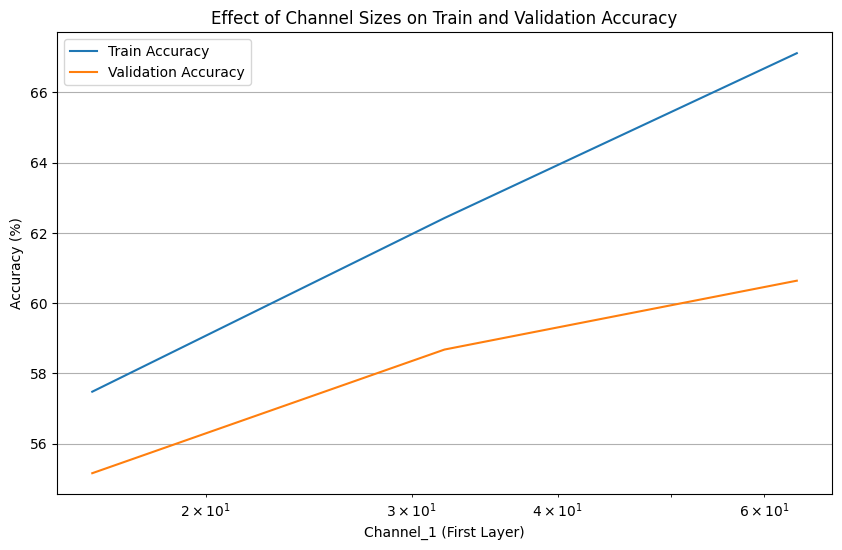

In [ ]:
# Define the channel size configurations to test
channel_sizes = [
    (16, 8),
    (32, 16),
    (64, 32)
]

best_learning_rate = 0.0010  # Replace with the best learning rate found earlier
best_optimizer_fn = lambda model: torch.optim.AdamW(model.parameters(), lr=best_learning_rate)  # Replace with the best optimizer
best_activation_fn = nn.PReLU()  # Replace with the best activation function found earlier

results = {"Channel_1": [], "Train Accuracy": [], "Validation Accuracy": []}


# We test the three-layer ConvNet with different channel sizes. Train the   
# model and record the train and validation accuracy for each configuration.   


for channel_1, channel_2 in channel_sizes:
    print(f"Testing channel sizes: Channel_1={channel_1}, Channel_2={channel_2}")

    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=channel_1, kernel_size=5, padding=2, bias=True),
        best_activation_fn,
        nn.Conv2d(in_channels=channel_1, out_channels=channel_2, kernel_size=3, padding=1, bias=True),
        best_activation_fn,
        nn.Flatten(),
        nn.Linear(channel_2 * 32 * 32, 10, bias=True)
    )

    model = model.to(device)

    optimizer = best_optimizer_fn(model)

    train_part3(model, optimizer)

    train_acc = check_accuracy_part3(train_loader, model)

    val_acc = check_accuracy_part3(val_loader, model)

    results["Channel_1"].append(channel_1)
    results["Train Accuracy"].append(train_acc)
    results["Validation Accuracy"].append(val_acc)

    print(f"Channel_1={channel_1}, Train Accuracy: {train_acc:.2f}%, Validation Accuracy: {val_acc:.2f}%\n")

# Plot the results
import matplotlib.pyplot as plt

def plot_channel_size_results(results):
    plt.figure(figsize=(10, 6))
    plt.plot(results["Channel_1"], results["Train Accuracy"], label="Train Accuracy")
    plt.plot(results["Channel_1"], results["Validation Accuracy"], label="Validation Accuracy")
    plt.xscale("log")  # Log scale for better visibility of channel sizes
    plt.xlabel("Channel_1 (First Layer)")
    plt.ylabel("Accuracy (%)")
    plt.title("Effect of Channel Sizes on Train and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_channel_size_results(results)

## Sequential API: Evaluate the final ConvNet model on the test set of CIFAR-10

By using the best configuration found during the previous experiments (optimizer, learning rate, activation function, and channel sizes), we train the model for 5 epoch and evaluate its performance on the test set.

1.	We report the test accuracy.

2.	We compare it with the validation accuracy to assess if our model generalized well.

In [ ]:
# We train the three-layer ConvNet with the best configuration found during 
# the previous experiments and evaluate its performance on the test set. Train 
# the model for 5 epochs and report the test accuracy.                         

channel_1 = 64
channel_2 = 32
best_learning_rate = 0.0010
best_activation_fn = nn.PReLU()
best_optimizer_fn = lambda model: torch.optim.AdamW(model.parameters(), lr=best_learning_rate)

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=channel_1, kernel_size=5, padding=2, bias=True),
    best_activation_fn,
    nn.Conv2d(in_channels=channel_1, out_channels=channel_2, kernel_size=3, padding=1, bias=True),
    best_activation_fn,
    nn.Flatten(),
    nn.Linear(channel_2 * 32 * 32, 10, bias=True)
)

model = model.to(device)

optimizer = best_optimizer_fn(model)

num_epochs = 5
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    train_part3(model, optimizer)
    val_acc = check_accuracy_part3(val_loader, model)
    print(f"Validation Accuracy after epoch {epoch + 1}: {val_acc:.2f}%\n")

test_acc = check_accuracy_part3(test_loader, model)

print(f"Test Accuracy: {test_acc:.2f}%")

Epoch 1/5
Iteration 0, loss = 2.2917
Checking accuracy on the val set
Got 785 / 5000 correct (15.70%)

Iteration 100, loss = 1.6887
Checking accuracy on the val set
Got 2321 / 5000 correct (46.42%)

Iteration 200, loss = 1.3624
Checking accuracy on the val set
Got 2346 / 5000 correct (46.92%)

Iteration 300, loss = 1.3700
Checking accuracy on the val set
Got 2784 / 5000 correct (55.68%)

Iteration 400, loss = 1.1720
Checking accuracy on the val set
Got 2946 / 5000 correct (58.92%)

Iteration 500, loss = 1.0468
Checking accuracy on the val set
Got 2992 / 5000 correct (59.84%)

Iteration 600, loss = 1.1362
Checking accuracy on the val set
Got 3099 / 5000 correct (61.98%)

Iteration 700, loss = 1.1730
Checking accuracy on the val set
Got 3027 / 5000 correct (60.54%)

Checking accuracy on the val set
Got 3145 / 5000 correct (62.90%)
Validation Accuracy after epoch 1: 62.90%

Epoch 2/5
Iteration 0, loss = 0.9988
Checking accuracy on the val set
Got 3074 / 5000 correct (61.48%)

Iteration 10

# Train ResNet-18 from scratch

So far, we’ve tried to design and train a **custom** three-layer convolutional network to the best of our ability.

However, in the literature, there are **well-known** convolutional architectures that are highly effective for image classification tasks.

Now will will do these 4 steps:

1.	Load a pre-defined [ResNet-18](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) model from the `torchvision.models` library.

2.	Modify it for CIFAR-10 classification (10 output classes).

3.	Train it from scratch for 5 epochs using the train_part3 function.

4.	Report the validation accuracy after each epoch and evaluate the test accuracy at the end.

In [ ]:
import torchvision.models as models
# We load the ResNet-18 model from torchvision, modify it for CIFAR-10,     
# train it from scratch for 5 epochs, and evaluate on the test set.            

model = models.resnet18()

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

for epoch in range(5):
    print(f"Epoch {epoch + 1}/5")
    train_part3(model, optimizer)

    val_acc = check_accuracy_part3(val_loader, model)
    print(f"Validation Accuracy after epoch {epoch + 1}: {val_acc:.2f}%\n")

test_acc = check_accuracy_part3(test_loader, model)
print(f"Test Accuracy: {test_acc:.2f}%")

Epoch 1/5
Iteration 0, loss = 2.4921
Checking accuracy on the val set
Got 523 / 5000 correct (10.46%)

Iteration 100, loss = 1.4463
Checking accuracy on the val set
Got 2031 / 5000 correct (40.62%)

Iteration 200, loss = 1.5549
Checking accuracy on the val set
Got 2318 / 5000 correct (46.36%)

Iteration 300, loss = 1.4640
Checking accuracy on the val set
Got 2411 / 5000 correct (48.22%)

Iteration 400, loss = 1.1840
Checking accuracy on the val set
Got 2791 / 5000 correct (55.82%)

Iteration 500, loss = 1.2843
Checking accuracy on the val set
Got 2878 / 5000 correct (57.56%)

Iteration 600, loss = 1.0679
Checking accuracy on the val set
Got 2968 / 5000 correct (59.36%)

Iteration 700, loss = 1.0961
Checking accuracy on the val set
Got 2916 / 5000 correct (58.32%)

Checking accuracy on the val set
Got 2899 / 5000 correct (57.98%)
Validation Accuracy after epoch 1: 57.98%

Epoch 2/5
Iteration 0, loss = 1.1889
Checking accuracy on the val set
Got 2909 / 5000 correct (58.18%)

Iteration 10

# Fine-tune a pre-trained ResNet-18

### Fine-tune only the classifier

Now we will explore **transfer learning** by leveraging a pretrained ResNet-18 model. Instead of training the entire model from scratch, we will:

1.	Load a [ResNet-18](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) model pretrained on [ImageNet-1k](https://www.image-net.org/download.php) using `torchvision.models`.

2.	Replace the final fully connected layer to output 10 classes (for CIFAR-10).

3.	Freeze all layers except the classifier.

4.	Train the model for 5 epochs, fine-tuning only the classifier, and evaluate its performance on the test set.



In [ ]:
import torchvision.models as models


# We are performing transfer learning with a pretrained ResNet-18 model. Replace  
# the final layer for CIFAR-10 classification, freeze all other layers, and   
# fine-tune the classifier for 5 epochs. Evaluate the model on the test set.  

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 10)

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

learning_rate = 1e-2
optimizer = optim.AdamW(model.fc.parameters(), lr=learning_rate)

for epoch in range(5):
    print(f"Epoch {epoch + 1}/5")
    train_part3(model, optimizer)

    val_acc = check_accuracy_part3(val_loader, model)
    print(f"Validation Accuracy after epoch {epoch + 1}: {val_acc:.2f}%\n")

test_acc = check_accuracy_part3(test_loader, model)
print(f"Test Accuracy: {test_acc:.2f}%")

Epoch 1/5
Iteration 0, loss = 2.9384
Checking accuracy on the val set
Got 563 / 5000 correct (11.26%)

Iteration 100, loss = 2.0063
Checking accuracy on the val set
Got 1849 / 5000 correct (36.98%)

Iteration 200, loss = 2.5651
Checking accuracy on the val set
Got 1923 / 5000 correct (38.46%)

Iteration 300, loss = 1.9912
Checking accuracy on the val set
Got 1785 / 5000 correct (35.70%)

Iteration 400, loss = 2.0362
Checking accuracy on the val set
Got 1948 / 5000 correct (38.96%)

Iteration 500, loss = 1.8402
Checking accuracy on the val set
Got 1952 / 5000 correct (39.04%)

Iteration 600, loss = 1.8766
Checking accuracy on the val set
Got 1753 / 5000 correct (35.06%)

Iteration 700, loss = 1.8983
Checking accuracy on the val set
Got 1942 / 5000 correct (38.84%)

Checking accuracy on the val set
Got 1910 / 5000 correct (38.20%)
Validation Accuracy after epoch 1: 38.20%

Epoch 2/5
Iteration 0, loss = 2.3141
Checking accuracy on the val set
Got 1839 / 5000 correct (36.78%)

Iteration 10

### Fine-tune the whole network

Now we will fine-tune the entire pretrained ResNet-18 model for CIFAR-10 classification. Instead of freezing the backbone, we will:

1.	Load a [ResNet-18](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) model pretrained on ImageNet using `torchvision.models`.

2.	Replace the final fully connected layer to output 10 classes (for CIFAR-10).

3.	Fine-tune all layers of the model (i.e., allow updates to the entire network).

4.	Train the model for 5 epochs and evaluate its performance on the test set.

In [ ]:
import torchvision.models as models

# We fine-tune the entire pretrained ResNet-18 model for CIFAR-10. Replace 
# the final layer for CIFAR-10 classification and update all model layers.    

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

for epoch in range(5):
    print(f"Epoch {epoch + 1}/5")
    train_part3(model, optimizer)

    val_acc = check_accuracy_part3(val_loader, model)
    print(f"Validation Accuracy after epoch {epoch + 1}: {val_acc:.2f}%\n")

test_acc = check_accuracy_part3(test_loader, model)
print(f"Test Accuracy: {test_acc:.2f}%")

Epoch 1/5
Iteration 0, loss = 2.5206
Checking accuracy on the val set
Got 762 / 5000 correct (15.24%)

Iteration 100, loss = 1.0045
Checking accuracy on the val set
Got 2946 / 5000 correct (58.92%)

Iteration 200, loss = 1.0299
Checking accuracy on the val set
Got 3084 / 5000 correct (61.68%)

Iteration 300, loss = 0.7790
Checking accuracy on the val set
Got 3393 / 5000 correct (67.86%)

Iteration 400, loss = 0.8136
Checking accuracy on the val set
Got 3468 / 5000 correct (69.36%)

Iteration 500, loss = 0.8220
Checking accuracy on the val set
Got 3599 / 5000 correct (71.98%)

Iteration 600, loss = 0.7421
Checking accuracy on the val set
Got 3547 / 5000 correct (70.94%)

Iteration 700, loss = 0.6442
Checking accuracy on the val set
Got 3689 / 5000 correct (73.78%)

Checking accuracy on the val set
Got 3702 / 5000 correct (74.04%)
Validation Accuracy after epoch 1: 74.04%

Epoch 2/5
Iteration 0, loss = 0.7790
Checking accuracy on the val set
Got 3657 / 5000 correct (73.14%)

Iteration 10

# Technical Report



| Model | Test Accuracy | Validation Accuracy |
|----------|----------|----------|
| Custom ConvNet   | 62.14%   | 63.16%   |
| ResNet-18 (Trained from Scratch)    | 73.53% | 73.52%   |
| ResNet-18 (Classifier Fine-Tuning)   | 31.78%  | 31.14%   |
| ResNet-18 (Full Fine-Tuning)    | 78.94%   | 79.12%  |

1. Performance Comparison:

ResNet-18 (Full Fine-Tuning) achieved the highest validation accuracy (79.12%) and test accuracy (78.94%).

It outperformed the other approaches because:

1.1 The pretrained backbone leveraged strong feature representations from ImageNet.

1.2 Fine-tuning all layers allowed the model to adapt fully to CIFAR-10-specific features.


2. Efficiency:

2.1 ResNet-18 (Classifier Fine-Tuning) was the most efficient in terms of training time and resource usage but had poor accuracy (~31.78%).

2.2 Custom ConvNet was more efficient than training ResNet-18 from scratch but required significant manual effort to design.

2.3 ResNet-18 (Full Fine-Tuning) offered a good balance of efficiency and performance.

3. Recommendations

Best Approach for CIFAR-10:

ResNet-18 (Full Fine-Tuning).

3.1 Accuracy:

Achieved the highest test accuracy (78.94%), showing strong generalization to CIFAR-10.

3.2 Efficiency:

Training was faster than training ResNet-18 from scratch and less resource-intensive.

3.3 Ease of Implementation:

Leveraging a pretrained model with minor modifications is straightforward and reduces the need for extensive hyperparameter tuning.
